In [1]:
# -*- coding: utf-8 -*-
"""
Created on Fri Dec  3 14:55:42 2021

@author: ladretp
"""

# Standard library imports
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.cm as cm

import pickle
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, balanced_accuracy_score
from sklearn.neural_network import MLPClassifier as MLPC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.metrics import balanced_accuracy_score,classification_report
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

import utils_ClassIm as utils

# import conversion_data_base as conversion
from sklearn.svm import SVC

# import pour la partie CNN


from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

from tensorflow.keras import backend as K 

#import transfer

from tensorflow.keras.applications.vgg16 import VGG16

from tensorflow.keras.models import Model
#########################################################################""




plt.close('all')


2025-11-19 13:58:46.107538: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:

# Main

# Partie 1.1 Recuperation de la base de données type DataFrame
database = pd.read_csv('./database.csv')
# Paramètres

# Etude sur catégorie 2 classes == 0 ou 8 classes == 1
ColLabels = 1

#remettre les données dans l'ordre des images

base_ordre=database.sort_values(by=['Numero'])

# Etude sur catégorie 2 classes ColLabels=0 ou 8 classes ColLabels= 1 uniquement
ColLabels = 1

########### visualisation des données ###########

T = database.describe()  #on représente les statistiques descriptives
print(T)


            Numero  GaborFeature0  GaborFeature1  GaborFeature2  \
count  2688.000000   2.688000e+03   2.688000e+03   2.688000e+03   
mean   1343.500000   1.850372e-17   7.004979e-17   1.321694e-17   
std     776.103086   1.000186e+00   1.000186e+00   1.000186e+00   
min       0.000000  -5.507909e-01  -5.507426e-01  -6.685841e-01   
25%     671.750000  -4.945687e-01  -4.913480e-01  -5.779625e-01   
50%    1343.500000  -3.604874e-01  -3.244246e-01  -3.408673e-01   
75%    2015.250000   7.276819e-02   9.053203e-02   1.870731e-01   
max    2687.000000   1.434079e+01   2.069380e+01   1.271028e+01   

       GaborFeature3  GaborFeature4  GaborFeature5  GaborFeature6  \
count   2.688000e+03   2.688000e+03   2.688000e+03   2.688000e+03   
mean    1.004487e-16  -1.206046e-17   4.229421e-17  -8.987520e-17   
std     1.000186e+00   1.000186e+00   1.000186e+00   1.000186e+00   
min    -7.358574e-01  -9.051396e-01  -9.724596e-01  -9.628479e-01   
25%    -6.146567e-01  -6.771426e-01  -6.981778e-01 

In [3]:
# Affichage des boxplots triés par 'Classe'
# On ne trace que les colonnes numériques pour éviter les erreurs (p.ex. la colonne 'Classe' est de type object)
numeric_cols = database.select_dtypes(include=[np.number]).columns.tolist()

# Optionnel : exclure la colonne 'Numero' si elle n'est pas pertinente
if 'Numero' in numeric_cols:
    numeric_cols.remove('Numero')
"""
for column in numeric_cols:
    plt.figure(figsize=(8, 6))
    database.boxplot(column=column, by='SousClasse', grid=False)
    plt.title(f"Boxplot de {column} par 'SousClasse'")
    plt.xlabel('SousClasse')
    plt.ylabel(column)
    plt.show()
"""

'\nfor column in numeric_cols:\n    plt.figure(figsize=(8, 6))\n    database.boxplot(column=column, by=\'SousClasse\', grid=False)\n    plt.title(f"Boxplot de {column} par \'SousClasse\'")\n    plt.xlabel(\'SousClasse\')\n    plt.ylabel(column)\n    plt.show()\n'

In [4]:
X1 = database.copy()
le = LabelEncoder()

# Encoder les classes en valeurs numériques
y_encoded = le.fit_transform(X1['SousClasse'])

# Sélectionner toutes les lignes (pas seulement [:2]) et les colonnes numériques
numeric_cols = X1.select_dtypes(include=[np.number]).columns.tolist()
if 'Numero' in numeric_cols:
    numeric_cols.remove('Numero')

"""
# Créer la matrice de dispersion
pd.plotting.scatter_matrix(X1[numeric_cols], c=y_encoded, figsize=(15, 15), alpha=0.8, cmap='viridis')
plt.suptitle('Matrice de dispersion colorée par SousClasse')
plt.show()
"""

"\n# Créer la matrice de dispersion\npd.plotting.scatter_matrix(X1[numeric_cols], c=y_encoded, figsize=(15, 15), alpha=0.8, cmap='viridis')\nplt.suptitle('Matrice de dispersion colorée par SousClasse')\nplt.show()\n"

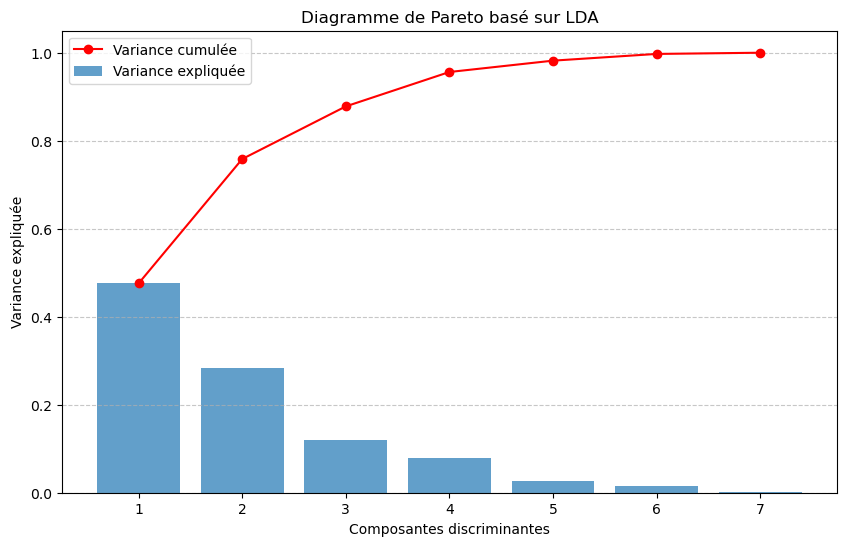

In [5]:

############  ALD ###########


lda = LinearDiscriminantAnalysis() 

# Sélectionner uniquement les colonnes numériques (exclure 'Classe', 'SousClasse', 'Numero')
X1_num = X1.select_dtypes(include=[np.number]).columns.tolist()
if 'Numero' in X1_num:
    X1_num.remove('Numero')

# Appliquer LDA
coord_lda = lda.fit_transform(X1[X1_num], y_encoded)

# Calculer la variance expliquée par chaque composante discriminante
explained_variance_ratio = lda.explained_variance_ratio_

# Créer un diagramme de Pareto
sorted_indices = np.argsort(explained_variance_ratio)[::-1]
sorted_variance = explained_variance_ratio[sorted_indices]
cumulative_variance = np.cumsum(sorted_variance)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(sorted_variance) + 1), sorted_variance, alpha=0.7, label='Variance expliquée')
plt.plot(range(1, len(sorted_variance) + 1), cumulative_variance, marker='o', color='r', label='Variance cumulée')

plt.xlabel('Composantes discriminantes')
plt.ylabel('Variance expliquée')
plt.title('Diagramme de Pareto basé sur LDA')
plt.xticks(range(1, len(sorted_variance) + 1))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

avec deux variables on n'aurait que 70% de précision, donc on a besoin de plus
au moins 5 ou 6 composantes discriminantes au minimum

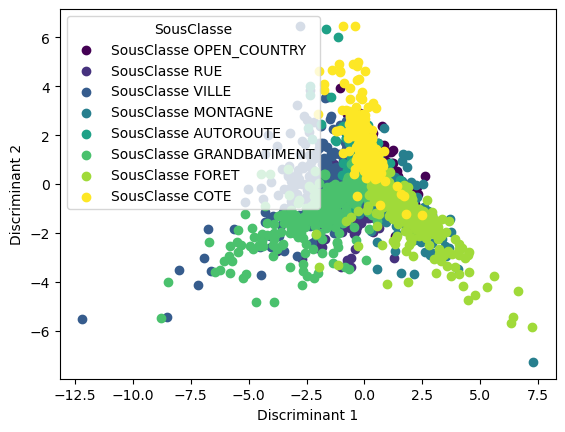

In [6]:
plt.figure()

# Création d'une palette de couleurs, juste esthétique
unique_codes = X1['SousClasse'].unique()
colors = cm.viridis(np.linspace(0, 1, len(unique_codes)))  # Génère des couleurs distinctes
color_map = dict(zip(unique_codes, colors))  # Associe chaque code à une couleur

# Tracé des points avec les couleurs correspondantes
for SousClasse in unique_codes:
    mask = X1['SousClasse'] == SousClasse
    plt.scatter(coord_lda[mask, 0], coord_lda[mask, 1], color=color_map[SousClasse], label=f'SousClasse {SousClasse}')     #on sélectionne les composantes discriminantes 1 et 2

# Ajout des étiquettes et de la légende
plt.xlabel('Discriminant 1')
plt.ylabel('Discriminant 2')
plt.legend(title='SousClasse')
plt.show()

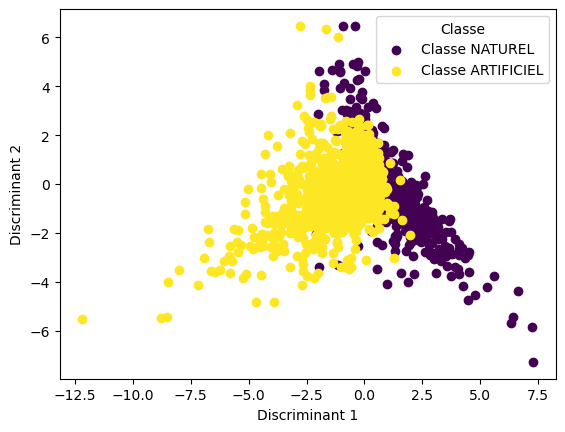

In [7]:
plt.figure()

# Création d'une palette de couleurs, juste esthétique
unique_codes = X1['Classe'].unique()
colors = cm.viridis(np.linspace(0, 1, len(unique_codes)))  # Génère des couleurs distinctes
color_map = dict(zip(unique_codes, colors))  # Associe chaque code à une couleur

# Tracé des points avec les couleurs correspondantes
for Classe in unique_codes:
    mask = X1['Classe'] == Classe
    plt.scatter(coord_lda[mask, 0], coord_lda[mask, 1], color=color_map[Classe], label=f'Classe {Classe}')     #on sélectionne les composantes discriminantes 1 et 2

# Ajout des étiquettes et de la légende
plt.xlabel('Discriminant 1')
plt.ylabel('Discriminant 2')
plt.legend(title='Classe')
plt.show()

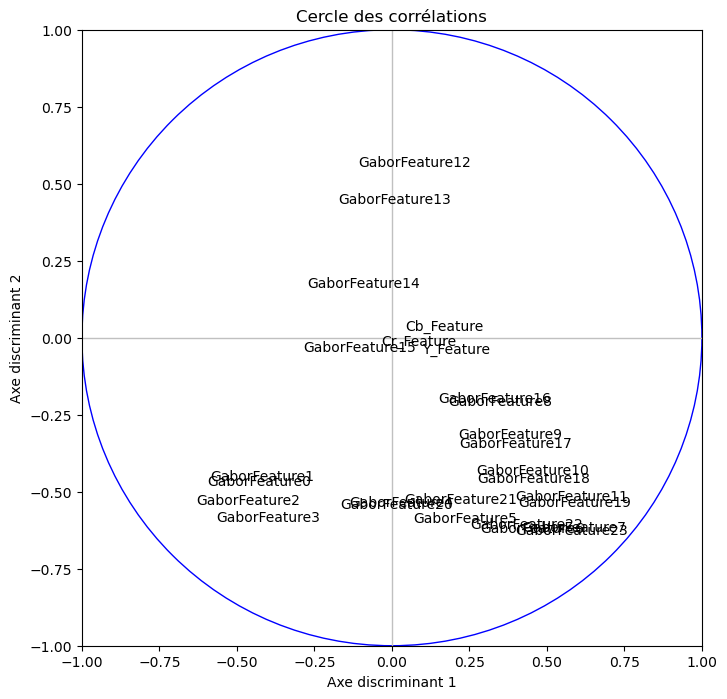

In [8]:
# Cercle des corrélations
fig, axes = plt.subplots(figsize=(8, 8))
axes.set_xlim(-1, 1)
axes.set_ylim(-1, 1)

# Calcul des corrélations entre les variables et les axes discriminants
# On utilise uniquement les features numériques (celles utilisées dans LDA)
for i, feature in enumerate(X1_num):
    # Calcul des coordonnées des variables sur le cercle
    x_corr = np.corrcoef(X1[feature], coord_lda[:, 0])[0, 1]
    y_corr = np.corrcoef(X1[feature], coord_lda[:, 1])[0, 1]
    
    # Affichage des noms des variables
    plt.annotate(feature, (x_corr, y_corr))

# Ajout des axes
plt.plot([-1, 1], [0, 0], color='silver', linestyle='-', linewidth=1)
plt.plot([0, 0], [-1, 1], color='silver', linestyle='-', linewidth=1)

# Ajout du cercle
cercle = plt.Circle((0, 0), 1, color='blue', fill=False)
axes.add_artist(cercle)

# Titres et affichage
plt.title("Cercle des corrélations")
plt.xlabel("Axe discriminant 1")
plt.ylabel("Axe discriminant 2")
plt.grid(False)
plt.show()

In [9]:
# Charger la base de données
database = pd.read_csv('./database.csv')

# Encoder les classes en valeurs numériques
yt = le.fit_transform(database['Classe'])

# On exclut 'Numero', 'Classe' et 'SousClasse'
feature_cols = [col for col in database.columns if col not in ['Numero', 'Classe', 'SousClasse']]
X = database[feature_cols].values

# Split train/test pour créer l'entrainement et le test
X_train, X_test, y_train, y_test = train_test_split(X, yt, test_size=0.2)


In [10]:
# Supposons que X_train_sous_classe et y_train_sous_classe existent

# 1. Définir le modèle et la grille de paramètres
mlpc = MLPC(max_iter=1000, random_state=42) # Ajout du random_state pour la reproductibilité
params = {
    "hidden_layer_sizes": [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    "activation": ('identity', 'logistic', 'tanh', 'relu')
}

# 2. Configurer le GridSearchCV
# Notez le cv=5 et scoring='balanced_accuracy' ICI
gridSearchClassifier = GridSearchCV(
    mlpc,
    params,
    verbose=4,
    return_train_score=True,
    n_jobs=-1,  # Utilise tous les processeurs
    cv=5,       # C'est ICI qu'on définit la validation croisée
    scoring='balanced_accuracy'
)

# 3. Lancer la recherche des meilleurs paramètres
print("Début du GridSearchCV...")
# On entraîne le GridSearchCV directement sur les données d'entraînement
gridSearchClassifier.fit(X_train, y_train)

print("Recherche terminée !")

# 4. Afficher les résultats
print("--- Meilleurs Résultats ---")
print(f"Meilleur score (balanced_accuracy) : {gridSearchClassifier.best_score_:.4f}")
print(f"Meilleurs paramètres : {gridSearchClassifier.best_params_}")

meilleur_modele_mlpc = gridSearchClassifier.best_estimator_

y_pred = meilleur_modele_mlpc.predict(X_test)
print("Classification Report :\n", classification_report(y_test, y_pred))


Début du GridSearchCV...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV 3/5] END activation=identity, hidden_layer_sizes=30;, score=(train=0.890, test=0.901) total time=   1.3s
[CV 2/5] END activation=identity, hidden_layer_sizes=20;, score=(train=0.900, test=0.881) total time=   1.4s
[CV 1/5] END activation=identity, hidden_layer_sizes=30;, score=(train=0.912, test=0.873) total time=   1.6s
[CV 4/5] END activation=identity, hidden_layer_sizes=10;, score=(train=0.896, test=0.892) total time=   1.7s
[CV 1/5] END activation=identity, hidden_layer_sizes=10;, score=(train=0.910, test=0.875) total time=   1.8s
[CV 5/5] END activation=identity, hidden_layer_sizes=10;, score=(train=0.890, test=0.912) total time=   1.9s
[CV 3/5] END activation=identity, hidden_layer_sizes=10;, score=(train=0.890, test=0.899) total time=   1.8s
[CV 5/5] END activation=identity, hidden_layer_sizes=30;, score=(train=0.891, test=0.918) total time=   1.8s
[CV 2/5] END activation=identity, hidden_

/home/mflores/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/mflores/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/mflores/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV 2/5] END activation=logistic, hidden_layer_sizes=10;, score=(train=0.930, test=0.900) total time=   6.2s
[CV 4/5] END activation=logistic, hidden_layer_sizes=10;, score=(train=0.928, test=0.901) total time=   5.7s
[CV 5/5] END activation=logistic, hidden_layer_sizes=10;, score=(train=0.926, test=0.924) total time=   5.7s
[CV 1/5] END activation=logistic, hidden_layer_sizes=10;, score=(train=0.936, test=0.889) total time=   6.4s
[CV 3/5] END activation=logistic, hidden_layer_sizes=10;, score=(train=0.922, test=0.929) total time=   5.9s


/home/mflores/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/mflores/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV 1/5] END activation=logistic, hidden_layer_sizes=20;, score=(train=0.949, test=0.890) total time=   7.4s
[CV 4/5] END activation=logistic, hidden_layer_sizes=20;, score=(train=0.940, test=0.907) total time=   7.2s
[CV 3/5] END activation=logistic, hidden_layer_sizes=20;, score=(train=0.933, test=0.933) total time=   7.4s


...

[CV 5/5] END activation=relu, hidden_layer_sizes=40;, score=(train=0.984, test=0.924) total time=   8.3s
[CV 1/5] END activation=relu, hidden_layer_sizes=60;, score=(train=0.989, test=0.888) total time=   6.1s
[CV 3/5] END activation=relu, hidden_layer_sizes=50;, score=(train=0.986, test=0.924) total time=   7.0s
[CV 2/5] END activation=relu, hidden_layer_sizes=60;, score=(train=0.987, test=0.910) total time=   7.1s
[CV 2/5] END activation=relu, hidden_layer_sizes=50;, score=(train=0.994, test=0.901) total time=   9.3s
[CV 4/5] END activation=relu, hidden_layer_sizes=60;, score=(train=0.984, test=0.912) total time=   6.8s
[CV 5/5] END activation=relu, hidden_layer_sizes=60;, score=(train=0.981, test=0.925) total time=   6.9s
[CV 3/5] END activation=relu, hidden_layer_sizes=60;, score=(train=0.992, test=0.925) total time=   8.1s


/home/mflores/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/mflores/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV 5/5] END activation=relu, hidden_layer_sizes=50;, score=(train=0.993, test=0.936) total time=   9.9s
[CV 4/5] END activation=relu, hidden_layer_sizes=50;, score=(train=0.996, test=0.921) total time=  10.2s
[CV 1/5] END activation=relu, hidden_layer_sizes=70;, score=(train=0.996, test=0.889) total time=   9.5s
[CV 2/5] END activation=relu, hidden_layer_sizes=70;, score=(train=0.998, test=0.903) total time=   9.0s
[CV 1/5] END activation=relu, hidden_layer_sizes=80;, score=(train=0.994, test=0.901) total time=   7.9s
[CV 5/5] END activation=relu, hidden_layer_sizes=70;, score=(train=0.996, test=0.935) total time=   8.9s
[CV 5/5] END activation=relu, hidden_layer_sizes=80;, score=(train=0.981, test=0.939) total time=   6.2s
[CV 4/5] END activation=relu, hidden_layer_sizes=70;, score=(train=0.998, test=0.921) total time=   9.8s
[CV 3/5] END activation=relu, hidden_layer_sizes=70;, score=(train=0.997, test=0.928) total time=  11.6s
[CV 3/5] END activation=relu, hidden_layer_sizes=80;, s

/home/mflores/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


[CV 2/5] END activation=relu, hidden_layer_sizes=80;, score=(train=0.999, test=0.891) total time=  12.6s
[CV 5/5] END activation=relu, hidden_layer_sizes=90;, score=(train=0.990, test=0.939) total time=   8.4s
[CV 1/5] END activation=relu, hidden_layer_sizes=90;, score=(train=0.998, test=0.892) total time=  10.6s
[CV 4/5] END activation=relu, hidden_layer_sizes=90;, score=(train=0.999, test=0.919) total time=   9.7s
[CV 2/5] END activation=relu, hidden_layer_sizes=90;, score=(train=0.996, test=0.897) total time=  10.3s
[CV 3/5] END activation=relu, hidden_layer_sizes=90;, score=(train=0.997, test=0.936) total time=  10.3s
[CV 3/5] END activation=relu, hidden_layer_sizes=100;, score=(train=0.995, test=0.931) total time=   7.1s
[CV 5/5] END activation=relu, hidden_layer_sizes=100;, score=(train=0.996, test=0.931) total time=   6.5s
[CV 4/5] END activation=relu, hidden_layer_sizes=100;, score=(train=0.998, test=0.910) total time=   7.1s
Recherche terminée !
--- Meilleurs Résultats ---
Mei

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END ...............................C=0.1, kernel=linear; total time=   0.1s
[CV] END ...............................C=0.1, kernel=linear; total time=   0.1s
[CV] END ...............................C=0.1, kernel=linear; total time=   0.1s
[CV] END ...............................C=0.1, kernel=linear; total time=   0.1s
[CV] END ...............................C=0.1, kernel=linear; total time=   0.1s
[CV] END .................................C=1, kernel=linear; total time=   0.1s
[CV] END .................................C=0.1, kernel=poly; total time=   0.1s
[CV] END .................................C=0.1, kernel=poly; total time=   0.1s
[CV] END ..................................C=0.1, kernel=rbf; total time=   0.2s
[CV] END .................................C=1, kernel=linear; total time=   0.1s
[CV] END .................................C=0.1, kernel=poly; total time=   0.2s[CV] END ..................................C=0.1,

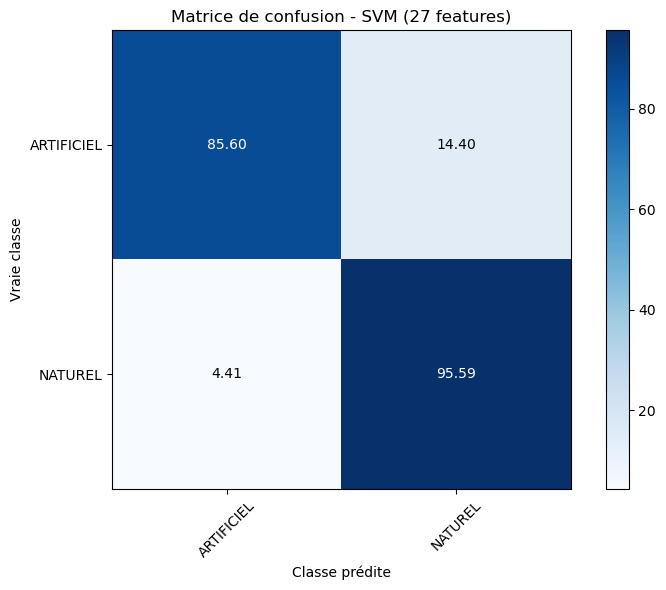


Nombre de vecteurs supports: 692
Nombre de features utilisées: 27


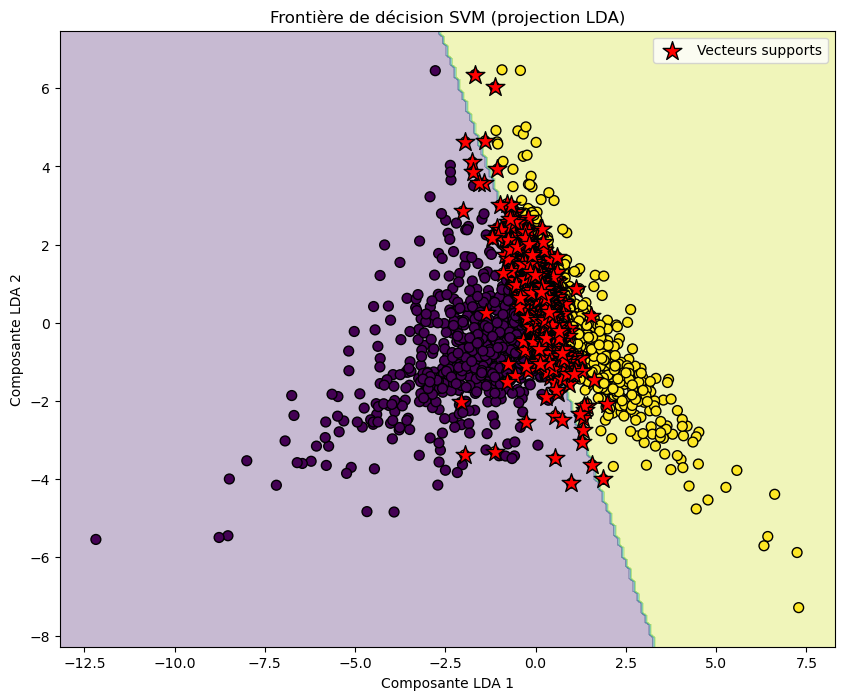

In [12]:
################# SVM ###################

# Définir la grille de paramètres pour le SVM
svc = SVC(kernel='linear')
param_grid = {
    'C': [0.1, 1, 10, 100, 1000, 10000],
    'kernel': ['linear', 'rbf', 'poly']
}

# GridSearchCV pour trouver les meilleurs paramètres
grid_svc = GridSearchCV(
    svc, 
    param_grid, 
    cv=5, 
    scoring='balanced_accuracy',
    n_jobs=-1,  # Utilise tous les processeurs, plus rapide
    verbose=2
)

grid_svc.fit(X_train, y_train)

print(f"Meilleurs paramètres SVM: {grid_svc.best_params_}")
print(f"Meilleur score: {grid_svc.best_score_:.4f}")

# Utiliser le meilleur modèle
svc = grid_svc.best_estimator_

# Apprentissage de la règle de décision sur les 27 features

svc.fit(X_train, y_train)

# Prédiction
y_pred = svc.predict(X_test)

# Évaluation
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}')
print('\nRapport de classification:')
print(classification_report(y_test, y_pred, target_names=le.classes_))      #permet de voir la précision de y_pred par rapport à y_test

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred, normalize='true') * 100
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Matrice de confusion - SVM (27 features)')
plt.colorbar()
tick_marks = np.arange(len(le.classes_))
plt.xticks(tick_marks, le.classes_, rotation=45)
plt.yticks(tick_marks, le.classes_)
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')

# Ajouter les valeurs dans chaque case
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], '.2f'),
             ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

# Informations sur le modèle
print(f'\nNombre de vecteurs supports: {len(svc.support_vectors_)}')
print(f'Nombre de features utilisées: {X.shape[1]}')

# Visualisation sur les 2 premières composantes LDA (pour visualisation uniquement)
Xs = coord_lda[:, :2]
svc_viz = SVC(C=10000, kernel='linear')
svc_viz.fit(Xs, yt)
plt.figure(figsize=(10, 8))
x_min, x_max = Xs[:, 0].min() - 1, Xs[:, 0].max() + 1
y_min, y_max = Xs[:, 1].min() - 1, Xs[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
Z = svc_viz.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(Xs[:,0], Xs[:,1], c=yt, marker='o', cmap='viridis', edgecolors='k', s=50)
plt.scatter(svc_viz.support_vectors_[:,0], svc_viz.support_vectors_[:,1], 
            c='r', marker='*', s=200, label='Vecteurs supports', edgecolors='black')
plt.xlabel('Composante LDA 1')
plt.ylabel('Composante LDA 2')
plt.title('Frontière de décision SVM (projection LDA)')
plt.legend()
plt.show()

Contenu Total: 2688
Classée Artificielle: 1216
Classée Naturelle: 1472
Classée Côte: 360
Classée Forêt: 328
Classée Autoroute: 260
Classée Ville: 308
Classée Montagne: 374
Classée Paysage Ouvert: 410
Classée Rue: 292
Classée Grand Batiment: 356
 
Epoch 1/3
48/48 ━━━━━━━━━━━━━━━━━━━━ 14s 282ms/step - accuracy: 0.3880 - loss: 1.6951 - val_accuracy: 0.1426 - val_loss: 2.7813
Epoch 2/3
48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 280ms/step - accuracy: 0.6100 - loss: 1.1913 - val_accuracy: 0.5287 - val_loss: 1.2707
Epoch 3/3
48/48 ━━━━━━━━━━━━━━━━━━━━ 13s 279ms/step - accuracy: 0.6904 - loss: 0.9443 - val_accuracy: 0.2341 - val_loss: 2.1232
{'accuracy': [0.38803985714912415, 0.6099667549133301, 0.6903654336929321], 'loss': [1.6951295137405396, 1.1912873983383179, 0.9443314075469971], 'val_accuracy': [0.14263565838336945, 0.5286821722984314, 0.23410852253437042], 'val_loss': [2.78131103515625, 1.270664095878601, 2.1232006549835205]}
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step


/home/mflores/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mflores/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mflores/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/mflo

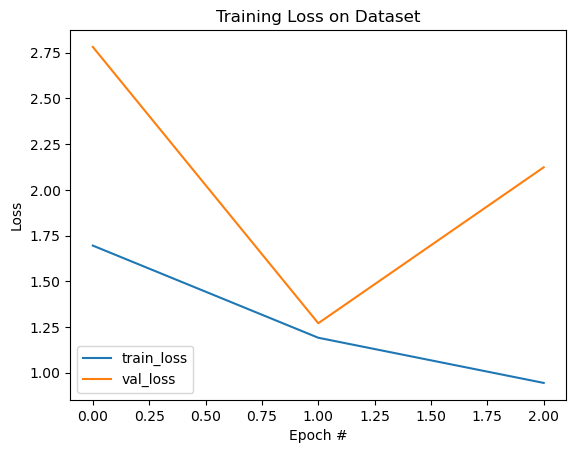

In [48]:
import pickle
# Partie 1.2
utils.show_database(database,1,2) # pour verifier les bases et afficher un exemple images


Base_im,label1,label2,Caract=utils.lire_images_et_carac("./images_128/images_128",'./database.csv',2688,sous_ech=2)

with open('data.tout_128', 'wb') as f:
     pickle.dump([Base_im,label1,label2,Caract],f)

# # Pour charger toutes les données de la base "à la matlab" comme un load
# # Ca suppose que le fichier data.pickle a déjà été fait
 
with open('data.tout_128', 'rb') as f:
    Base_im, label1, label2,caract = pickle.load(f)

Base_im=np.array(Base_im)   
caract=np.array(caract) 
    
Base_im=(Base_im/255)-0.5


Base_tot=list(zip(Base_im, caract))

datatrain, datatest, datalabeltrain, datalabeltest = train_test_split(Base_tot, label2-2, test_size=0.2, random_state=None)

imtrain,caractrain=zip(*datatrain)
imtest,caractest=zip(*datatest)


mc=[]
titre=[]
report=[]
resu_acc=[]
resu_acc_class=[]
int_conf=[]




I=datatrain[0][0]
(img_width, img_height, nb_plan)=np.shape(I)

#vérification pour que les entrées du réseau soient correctes
if K.image_data_format() == 'channels_first': 
    input_shape = (3, img_width, img_height) 
else: 
    input_shape = (img_width, img_height, 3) 
    
imdata=[]
imdata2=[]
for i in np.arange(len(datalabeltrain)):
    imdata.append(datatrain[i][0])
for i in np.arange(len(datalabeltest)):   
    imdata2.append(datatest[i][0])
imdatatrain=np.array(imdata)
imdatatest=np.array(imdata2)



#############################################################################################################
# Le transfert learning
#############################################################################################################

###################################################################################################################################
# CNN definition transfert learning
# load model without classifier layers
    
base_model= VGG16(include_top=False, input_shape=input_shape) #choisir la taille qui correspond à la taille des images étudiées
#base_model = InceptionV3(weights='imagenet', include_top=False)

# add a global spatial average pooling layer
x = base_model.output
x=Flatten()(x) #pour VGG16
#x = GlobalAveragePooling2D()(x) # A la place de Flatten()
# let's add a fully-connected layer
x = Dense(500, activation='relu')(x)
x = Dropout(0.4)(x)
#x = Dense(20, activation='relu')(x)
# and a logistic layer -- On a 8 classes en sortie
predictions = Dense(8, activation='softmax')(x)


# this is the model we will train
model = Model(inputs=base_model.input, outputs=predictions)

#####################################################################################################################
#Etape de fine-Tuning

#Pour inception
#Nbr_couches_gelees=249

#Pour VGG16
Nbr_couches_gelees=18
#####################################################################################################################

for layer in model.layers[:Nbr_couches_gelees]:
    layer.trainable = False
for layer in model.layers[Nbr_couches_gelees:]:
    layer.trainable = True

# on recompile le nouveau modèle
#model.compile(optimizer='rmsprop', loss='categorical_crossentropy',metrics=['accuracy'])
model.compile(optimizer='sgd', loss='categorical_crossentropy',metrics=['accuracy'])
n_epochs=3
  #nombre epoch pour le fine-tuning 
 

H=model.fit(
            imdatatrain, to_categorical(datalabeltrain),
            epochs=n_epochs,
            validation_split=0.3, verbose=1) #ici verbose = 2 
    #pour pouvoir ressortir les informations de loss et d'accuracy 
    #dans une variable obtenue avec la methode history : H.history
print(H.history)



N = np.arange(0, n_epochs)
plt.figure()
plt.plot(N, H.history["loss"], label="train_loss")
plt.plot(N, H.history["val_loss"], label="val_loss")
plt.legend(loc="lower left")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.title("Training Loss on Dataset")
  

labels_predit = model.predict(imdatatest)


mc.append(confusion_matrix(datalabeltest,np.argmax(labels_predit,axis=1)))


acc=balanced_accuracy_score(datalabeltest, np.argmax(labels_predit,axis=1))
resu_acc.append(acc)
titre.append(f'Transfert avec Inception, accuracy={acc:.2f}]')
resu=classification_report(datalabeltest,np.argmax(labels_predit,axis=1),target_names=['2','3','4','5','6','7','8','9'],output_dict=True)
report.append(classification_report(datalabeltest,np.argmax(labels_predit,axis=1),target_names=['2','3','4','5','6','7','8','9'],output_dict=True))

acc_class=np.arange(8)*0.0
for i in np.arange(0,8):
    acc_class[i]=np.around(resu[str(i+2)]['precision'],3)
resu_acc_class.append(acc_class)


Iniciando entrenamiento con Data Augmentation...
Epoch 1/30


/home/mflores/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


67/67 ━━━━━━━━━━━━━━━━━━━━ 31s 435ms/step - accuracy: 0.6317 - loss: 1.1153 - val_accuracy: 0.8104 - val_loss: 0.7179 - learning_rate: 1.0000e-04
Epoch 2/30
 1/67 ━━━━━━━━━━━━━━━━━━━━ 24s 372ms/step - accuracy: 0.7188 - loss: 1.2291

/home/mflores/anaconda3/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.7188 - loss: 1.2291 - val_accuracy: 0.8067 - val_loss: 0.7142 - learning_rate: 1.0000e-04
Epoch 3/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 27s 408ms/step - accuracy: 0.7885 - loss: 0.6602 - val_accuracy: 0.6803 - val_loss: 0.9187 - learning_rate: 1.0000e-04
Epoch 4/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.7500 - loss: 0.8545 - val_accuracy: 0.6859 - val_loss: 0.9109 - learning_rate: 1.0000e-04
Epoch 5/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 25s 377ms/step - accuracy: 0.8206 - loss: 0.5280 - val_accuracy: 0.8383 - val_loss: 0.4988 - learning_rate: 1.0000e-04
Epoch 6/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.8438 - loss: 0.5286 - val_accuracy: 0.8476 - val_loss: 0.4858 - learning_rate: 1.0000e-04
Epoch 7/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 25s 377ms/step - accuracy: 0.8442 - loss: 0.4647 - val_accuracy: 0.8587 - val_loss: 0.5233 - learning_rate: 1.0000e-04
Epoch 8/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.7500 - los

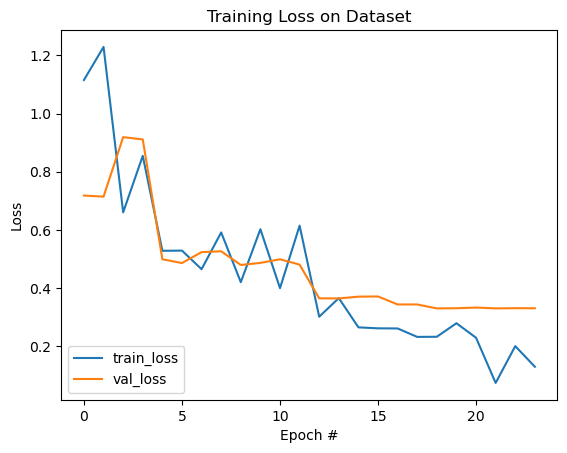

17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step
Balanced Accuracy: 0.9127
              precision    recall  f1-score   support

           2       0.92      0.88      0.90        83
           3       0.89      0.96      0.92        57
           4       0.93      0.91      0.92        44
           5       0.86      0.91      0.88        54
           6       0.88      0.94      0.91        65
           7       0.90      0.82      0.86        93
           8       0.90      0.93      0.91        67
           9       0.96      0.96      0.96        75

    accuracy                           0.91       538
   macro avg       0.91      0.91      0.91       538
weighted avg       0.91      0.91      0.91       538



In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, classification_report
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Importaciones adicionales para mejorar el rendimiento
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import backend as K 
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import utils_ClassIm as utils

plt.close('all')

# --- CARGA DE DATOS (Tu código original) ---

# utils.show_database(database,1,2) 

# Si necesitas regenerar el pickle, descomenta esto:
# Base_im, label1, label2, Caract = utils.lire_images_et_carac("./images_128/images_128", './database.csv', 2688, sous_ech=2)
# with open('data.tout_128', 'wb') as f:
#      pickle.dump([Base_im, label1, label2, Caract], f)

with open('data.tout_128', 'rb') as f:
    Base_im, label1, label2, caract = pickle.load(f)

Base_im = np.array(Base_im)   
caract = np.array(caract) 
    
# Normalización
Base_im = (Base_im / 255) - 0.5

Base_tot = list(zip(Base_im, caract))

datatrain, datatest, datalabeltrain, datalabeltest = train_test_split(Base_tot, label2-2, test_size=0.2, random_state=42)

imtrain, caractrain = zip(*datatrain)
imtest, caractest = zip(*datatest)

mc=[]
titre=[]
report=[]
resu_acc=[]
resu_acc_class=[]
int_conf=[]

I = datatrain[0][0]
(img_width, img_height, nb_plan) = np.shape(I)

if K.image_data_format() == 'channels_first': 
    input_shape = (3, img_width, img_height) 
else: 
    input_shape = (img_width, img_height, 3) 
    
imdata=[]
imdata2=[]
for i in np.arange(len(datalabeltrain)):
    imdata.append(datatrain[i][0])
for i in np.arange(len(datalabeltest)):   
    imdata2.append(datatest[i][0])
    
imdatatrain = np.array(imdata)
imdatatest = np.array(imdata2)

# Convertir etiquetas a one-hot encoding
y_train_cat = to_categorical(datalabeltrain)
y_test_cat = to_categorical(datalabeltest)

#################################################################################
# MEJORA 1: Data Augmentation
# Esto crea variaciones de las imágenes en tiempo real para evitar overfitting
#################################################################################
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

#################################################################################
# CNN definition transfert learning
#################################################################################
    
base_model = VGG16(include_top=False, input_shape=input_shape) 

# MEJORA 2: Arquitectura un poco más robusta (BatchNormalization)
x = base_model.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x) # Ayuda a estabilizar el aprendizaje
x = Dropout(0.5)(x)      # Aumentado a 0.5 para reducir overfitting
predictions = Dense(8, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

#################################################################################
# Etape de fine-Tuning
#################################################################################

# Congelamos capas base
Nbr_couches_gelees = 15 # Descongelamos un poco más para VGG (ajustable)
for layer in model.layers[:Nbr_couches_gelees]:
    layer.trainable = False
for layer in model.layers[Nbr_couches_gelees:]:
    layer.trainable = True

# MEJORA 3: Optimizador Adam con learning rate bajo y Callbacks
optimizer = Adam(learning_rate=1e-4) 

model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks para detener si no mejora y reducir el learning rate
callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)
]

# Aumentamos epochs (los callbacks lo pararán si es necesario)
n_epochs = 30 
batch_size = 32

print("Iniciando entrenamiento con Data Augmentation...")

# Usamos fit con el generador de datos
H = model.fit(
    datagen.flow(imdatatrain, y_train_cat, batch_size=batch_size),
    steps_per_epoch=len(imdatatrain) // batch_size,
    epochs=n_epochs,
    validation_data=(imdatatest, y_test_cat),
    callbacks=callbacks_list,
    verbose=1
)

print(H.history)

# --- VISUALIZACIÓN Y RESULTADOS (Tu código original) ---

# Ajustar N al número real de épocas ejecutadas (por si paró antes)
actual_epochs = len(H.history["loss"])
N = np.arange(0, actual_epochs)

plt.figure()
plt.plot(N, H.history["loss"], label="train_loss")
plt.plot(N, H.history["val_loss"], label="val_loss")
plt.legend(loc="lower left")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.title("Training Loss on Dataset")
plt.show() # Añadido show para asegurar que se ve

# Predicción
labels_predit = model.predict(imdatatest)
y_pred_classes = np.argmax(labels_predit, axis=1)

mc.append(confusion_matrix(datalabeltest, y_pred_classes))

acc = balanced_accuracy_score(datalabeltest, y_pred_classes)
resu_acc.append(acc)
titre.append(f'Transfert avec VGG16 (Optimized), accuracy={acc:.2f}]')

print(f"Balanced Accuracy: {acc:.4f}")

resu = classification_report(datalabeltest, y_pred_classes, target_names=['2','3','4','5','6','7','8','9'], output_dict=True)
print(classification_report(datalabeltest, y_pred_classes, target_names=['2','3','4','5','6','7','8','9']))

acc_class = np.arange(8)*0.0
for i in np.arange(0,8):
    acc_class[i] = np.around(resu[str(i+2)]['precision'], 3)
resu_acc_class.append(acc_class)

--- 1. Preparando datos ---
Datos listos. Entrada: (2150, 3, 3, 3), Salida: (2150, 8)


/home/mflores/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


--- Arquitectura del Modelo ---


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 3, 3, 32)       │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 3, 3, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,280 (368.28 KB)

 Trainable params: 94,280 (368.28 KB)

 Non-trainable params: 0 (0.00 B)


--- Iniciando Entrenamiento ---
Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6645 - loss: 0.8428 - val_accuracy: 0.8558 - val_loss: 0.3694
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8390 - loss: 0.3853 - val_accuracy: 0.8558 - val_loss: 0.3150
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8727 - loss: 0.3207 - val_accuracy: 0.9070 - val_loss: 0.2775
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8808 - loss: 0.2960 - val_accuracy: 0.9116 - val_loss: 0.2621
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8866 - loss: 0.2657 - val_accuracy: 0.9209 - val_loss: 0.2287
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8878 - loss: 0.2665 - val_accuracy: 0.9279 - val_loss: 0.2030
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9006 - loss: 0.2476 - val_accuracy: 0.9233 - val_loss: 0.2244
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9029 - loss: 0.2290 -

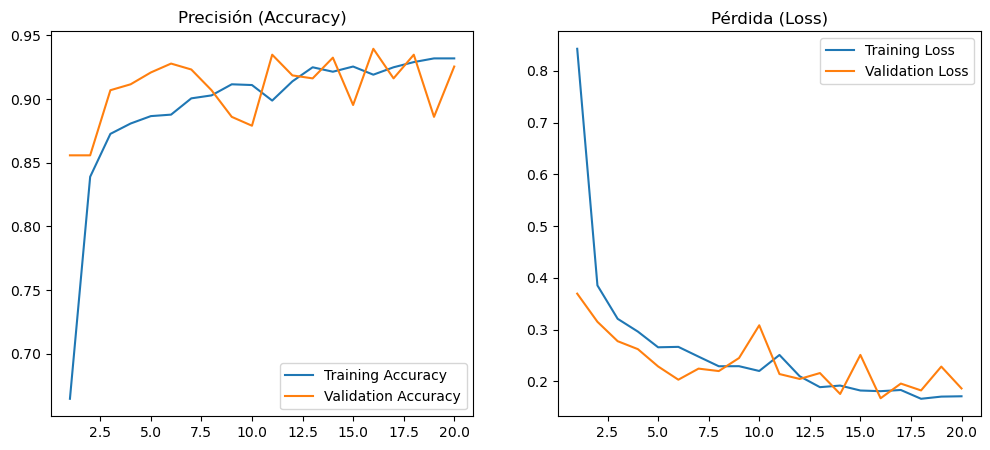


--- Evaluación en Base de Test ---
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

  ARTIFICIEL       0.94      0.89      0.92       243
     NATUREL       0.92      0.96      0.94       295

    accuracy                           0.93       538
   macro avg       0.93      0.92      0.93       538
weighted avg       0.93      0.93      0.93       538



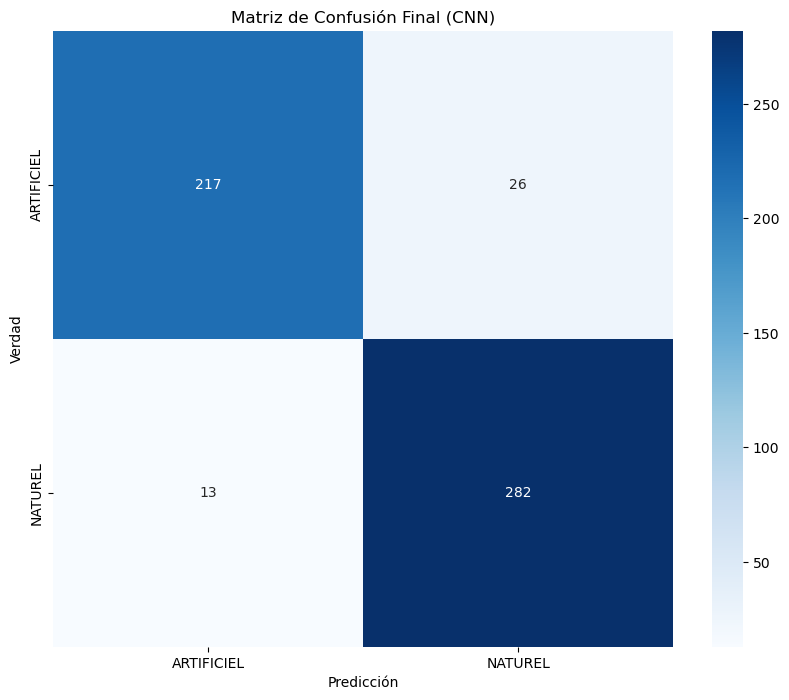

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 1. PREPARACIÓN DE DATOS
# ==========================================
print("--- 1. Preparando datos ---")

# Detectar dimensiones reales de las imágenes si están aplanadas
channels = 3

if X_train.ndim == 2:
    # Calcular altura y ancho basado en el tamaño total
    total_pixels = X_train.shape[1]
    img_height = img_width = int(np.sqrt(total_pixels // channels))
    
    # Redimensionar
    X_train_cnn = X_train.reshape(-1, img_height, img_width, channels)
    X_test_cnn = X_test.reshape(-1, img_height, img_width, channels)
else:
    X_train_cnn = X_train
    X_test_cnn = X_test
    img_height, img_width = X_train_cnn.shape[1:3]

# Convertir etiquetas a One-Hot Encoding (ej: 2 -> [0, 0, 1, 0...])
num_classes = 8
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(f"Datos listos. Entrada: {X_train_cnn.shape}, Salida: {y_train_cat.shape}")

# ==========================================
# 2. DEFINICIÓN DEL MODELO (Arquitectura LeNet)
# ==========================================
def build_lenet():
    # Aquí usamos 'Sequential' para apilar las capas
    model = Sequential()
    
    # Capa 1: Convolución con padding='same' para mantener dimensiones
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same', 
                     input_shape=(img_height, img_width, channels)))
    
    # Capa 2: Convolución (sin pooling para imágenes pequeñas)
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))

    # Aplanar para entrar al MLP
    model.add(Flatten())
    
    # Capa Densa (MLP)
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5)) # Evitar memorización
    
    # Salida
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

model = build_lenet()

# ==========================================
# 3. COMPILACIÓN (Usando SGD como pide el PDF)
# ==========================================
# SGD es el algoritmo que optimiza el modelo "Sequential"
opt = SGD(learning_rate=0.01, momentum=0.9) 
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

print("--- Arquitectura del Modelo ---")
model.summary()

# ==========================================
# 4. ENTRENAMIENTO
# ==========================================
print("\n--- Iniciando Entrenamiento ---")
history = model.fit(
    X_train_cnn, y_train_cat,
    epochs=20,          # Ajustar si es necesario
    batch_size=32, 
    validation_split=0.2, # 20% de entrenamiento se usa para validar en vivo
    verbose=1
)

# ==========================================
# 5. VISUALIZACIÓN DE CURVAS
# ==========================================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Precisión (Accuracy)')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Pérdida (Loss)')
plt.legend(loc='upper right')
plt.show()

# ==========================================
# 6. EVALUACIÓN FINAL (TEST)
# ==========================================
print("\n--- Evaluación en Base de Test ---")
# Predicción
y_pred_prob = model.predict(X_test_cnn)
y_pred_classes = np.argmax(y_pred_prob, axis=1)

# Reporte
# Nota: Asegúrate de que 'le' (LabelEncoder) esté definido en tu código anterior
print(classification_report(y_test, y_pred_classes, target_names=le.classes_))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Matriz de Confusión Final (CNN)')
plt.ylabel('Verdad')
plt.xlabel('Predicción')
plt.show()